# <center>Annotation d'images<br /> Workshop</center>

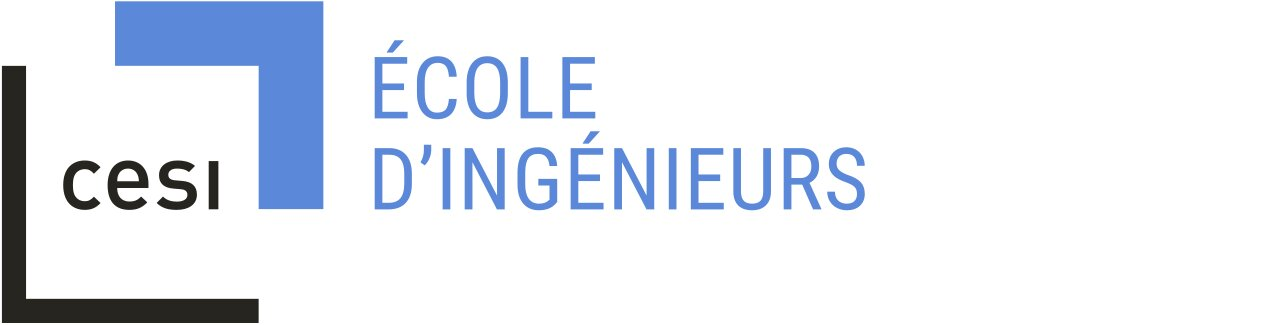
Concepteur : Nassim HADDAM
</div>

L'objectif de de ce workshop est de vous faire acquérir les notions nécessaires pour effectuer le workshop d'[annotation d'images](https://fr.wikipedia.org/wiki/Annotation_automatique_d%27images) (ou sous-titrage d'images). Dans ce workshop, vous allez devoir utiliser les CNNs (pour création d’attributs utiles à l’annotation) ainsi que les RNNs (pour faire l’annotation à proprement parler). Vous allez aussi devoir faire **beaucoup** de prétraitements. Ce workshop portera essentiellement sur cette partie et donnera des indications sur l'architecture du réseau qui servira à faire de l'annotation. On commencera d'abord par importer les bibliothèques qui nous intéressent.

Vous devez, donc, ré-exécuter les cellules correspondant à la préparation des données du workshop précédent en allant du chargement des données jusqu'au prétraitements des images et des annotations.
<br><br>
<b>Imports</b>

In [1]:
import tensorflow as tf

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import collections
import random
import re
import numpy as np
import os
import time
import json
from glob import glob
from PIL import Image
import pickle
from tqdm import tqdm

2025-04-22 14:38:18.639424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745325498.654997    3021 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745325498.659224    3021 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745325498.671056    3021 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745325498.671079    3021 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745325498.671080    3021 computation_placer.cc:177] computation placer alr

<b>Chargement des données</b>

In [ ]:
import json
import os
import random
import collections

# Dossier des annotations et images
annotation_file = "../../annotations/captions_train2014.json"
image_folder = "../../train2014/"

# Charger les annotations TRAIN (et uniquement celles-là !)
with open(annotation_file, 'r') as f:
    annotations = json.load(f)

# Grouper les annotations par image_id
image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = '<start> ' + val['caption'] + ' <end>'
    image_path = os.path.join(image_folder, 'COCO_train2014_' + '%012d.jpg' % val['image_id'])
    image_path_to_caption[image_path].append(caption)

# Prendre un sous-ensemble aléatoire d'images
image_paths = list(image_path_to_caption.keys())
train_image_paths = image_paths[:10000]  # tu peux ajuster ce nombre

print(f"{len(train_image_paths)} images sélectionnées.")

# Créer les listes d'annotations et de chemins d'images correspondantes
train_captions = []
img_name_vector = []

for image_path in train_image_paths:
    captions = image_path_to_caption[image_path]
    train_captions.extend(captions)
    img_name_vector.extend([image_path] * len(captions))

print(f"Total de {len(train_captions)} légendes pour {len(train_image_paths)} images.")


10000 images sélectionnées.
Total de 50024 légendes pour 10000 images.


50024 50024
<start> Two people standing together one holding a remote. <end>


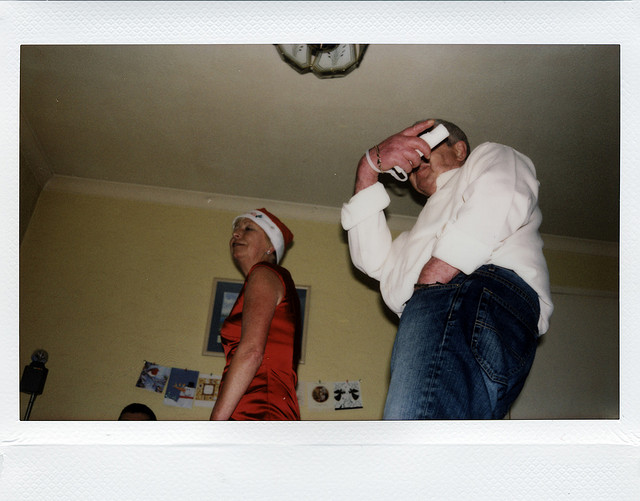

In [3]:
print(len(train_captions), len(img_name_vector))
print(train_captions[0])
Image.open(img_name_vector[0])

In [ ]:
# Telechargement du modèle InceptionV3 pré-entrainé avec la classification sur ImageNet
image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                weights='imagenet')

# Création d'une variable qui sera l'entrée du nouveau modèle de pré-traitement d'images
new_input = image_model.input

# Récupérer la dernière couche cachée qui contient l'image en représentation compacte
hidden_layer = image_model.layers[-1].output

# Modèle qui calcule une représentation dense des images avec InceptionV3
image_features_extract_model = tf.keras.Model(inputs=new_input, outputs=hidden_layer)


def load_image(image_path):
    """
    La fonction load_image a pour entrée le chemin d'une image et pour sortie un couple
    contenant l'image traitée ainsi que son chemin d'accès.
    La fonction load_image effectue les traitement suivant:
        1. Chargement du fichier correspondant au chemin d'accès image_path
        2. Décodage de l'image en RGB.
        3. Redimensionnement de l'image en taille (299, 299).
        4. Normalisation des pixels de l'image entre -1 et 1
    """
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

# Pré-traitement des images
# Prendre les noms des images
encode_train = sorted(set(img_name_vector))

# Creation d'une instance de "tf.data.Dataset" partant des noms des images 
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
# Division du données en batchs après application du pré-traitement fait par load_image
image_dataset = image_dataset.map(
  load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(16)

# Parcourir le dataset batch par batch pour effectuer le pré-traitement d'InceptionV3
for img, path in tqdm(image_dataset):
    # Passage des images dans le CNN pour récupérer les features
    batch_features = image_features_extract_model(img)

    # Redimensionnement de (batch_size, 8, 8, 2048) vers (batch_size, 64, 2048)
    batch_features = tf.reshape(batch_features,
                                (batch_features.shape[0], -1, batch_features.shape[3]))

    # Sauvegarde de chaque image prétraitée individuellement
    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        # Ajout de l'extension .npy pour le fichier sauvegardé
        np.save(path_of_feature, bf.numpy())

I0000 00:00:1745325520.818076    3021 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
100%|██████████| 625/625 [04:10<00:00,  2.50it/s]


**Pré-traitement des annotations** (Pour l'entrainement)

In [ ]:
# Trouver la taille maximale 
def calc_max_length(tensor):
    return max(len(t) for t in tensor)

# Chosir les 5000 mots les plus frequents du vocabulaire
top_k = 5000
#La classe Tokenizer permet de faire du pre-traitement de texte pour reseau de neurones 
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
# Construit un vocabulaire en se basant sur la liste train_captions
tokenizer.fit_on_texts(train_captions)

# Créer le token qui sert à remplir les annotations pour égaliser leurs longueurs
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

# Création des vecteurs (liste de token entiers) à partir des annotations (liste de mots)
train_seqs = tokenizer.texts_to_sequences(train_captions)

# Remplir chaque vecteur jusqu'à la longueur maximale des annotations
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

# Calcule la longueur maximale qui est utilisée pour stocker les poids d'attention 
# Elle servira plus tard pour l'affichage lors de l'évaluation
max_length = calc_max_length(train_seqs)

Sans entrainement

In [5]:
# Recharge du tokenizer
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

vocab_size = len(tokenizer.word_index) + 1

def calc_max_length(tensor):
    return max(len(t) for t in tensor)

# Si tu as encore tes captions d'entraînement :
train_seqs = tokenizer.texts_to_sequences(train_captions)
max_length = calc_max_length(train_seqs)

# 1 Formation du jeu d'entrainement et de test :
Vous devez ensuite séparer le dataset en deux partie : un jeu d'entrainement et un jeu de test. Le code qui effectue ces opérations est détaillé dans la cellule suivante.

In [6]:
import collections
import random

img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(img_name_vector, train_captions):
    img_to_cap_vector[img].append(cap)

img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

slice_index = int(len(img_keys) * 0.8)
img_name_train_keys = img_keys[:slice_index]
img_name_val_keys = img_keys[slice_index:]

img_name_train, cap_train = [], []
img_name_val, cap_val = [], []

for imgt in img_name_train_keys:
    img_name_train.extend([imgt] * len(img_to_cap_vector[imgt]))
    cap_train.extend(img_to_cap_vector[imgt])

for imgv in img_name_val_keys:
    img_name_val.extend([imgv] * len(img_to_cap_vector[imgv]))
    cap_val.extend(img_to_cap_vector[imgv])

# Affichage des tailles finales
len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)


(40014, 40014, 10010, 10010)

Création d’un jeu de données d’entrainement représenté par une instance [`tf.data.Dataset`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) partant du jeu de données de base (les noms des fichiers et des annotations du jeu d’entrainement). La classe `tf.data.Dataset` sert à représenter des jeu de données volumineux et facilitent les prétraitements de ceux-ci.

In [ ]:
# N'hésitez pas à modifier ces paramètres en fonction de votre machine
BATCH_SIZE = 64 # taille du batch
BUFFER_SIZE = 1000 # taille du buffer pour melanger les donnes
embedding_dim = 256
vocab_size = top_k + 1
units = 512 # Taille de la couche caché dans le RNN

num_steps = len(img_name_train) // BATCH_SIZE

# La forme du vecteur extrait à partir d'InceptionV3 est (64, 2048)
# Les deux variables suivantes representent la forme de ce vecteur
features_shape = 2048
attention_features_shape = 64

# Tokenisation + padding après split
train_seqs = tokenizer.texts_to_sequences(cap_train)
cap_train_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post', dtype='int32')

# Dataset correct
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train_vector))


def map_func(img_name, cap):
    img_path = img_name.decode('utf-8') + '.npy'
    img_tensor = np.load(img_path).astype(np.float32)

    return img_tensor, cap

# tf wrapper de map_func
def tf_map_func(img, cap):
    img_tensor, cap = tf.numpy_function(
        map_func,
        [img, cap],
        [tf.float32, tf.int32]
    )
    img_tensor.set_shape((64, 2048))   # <- très important pour la suite
    cap.set_shape([None])              # <- pour que le modèle sache ce qu'il reçoit
    return img_tensor, cap

# Appliquer map + shuffle + batch
dataset = dataset.map(tf_map_func, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)



In [8]:
# Tokenisation + padding après split
train_seqs = tokenizer.texts_to_sequences(cap_val)
cap_val_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post', dtype='int32')

# Dataset correct
dataset_val = tf.data.Dataset.from_tensor_slices((img_name_val, cap_val_vector))

dataset_val = dataset_val.map(tf_map_func, num_parallel_calls=tf.data.AUTOTUNE)
dataset_val = dataset_val.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [9]:
print("img_name_train[0]:", type(img_name_train[0]))
print("cap_train[0]:", type(cap_train_vector[0]), cap_train_vector[0])

img_name_train[0]: <class 'str'>
cap_train[0]: <class 'numpy.ndarray'> [  3   2  24 463   9   2  65 502  18   2  65 143   4   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


# 2 Le modèle :
Par rapport au modèle, la dernière couche convolutive d'`InceptionV3` est de la forme `(8, 8, 2048)`. Ce vecteur a été remodelé en la forme `(64, 2048)` lors de du stockage au niveau du disque. Ce vecteur est ensuite passé à travers l'encodeur CNN (qui se compose d'une seule couche entièrement connectée). Le RNN s'occupera de prédire pour ce vecteur le mot suivant dans l'annotation. [L'image](https://github.com/Hvass-Labs/TensorFlow-Tutorials/blob/master/22_Image_Captioning.ipynb) ci-dessous reprend un exemple d'une architecture très basique d'un système d'annotation utilisant un CNN et un RNN.

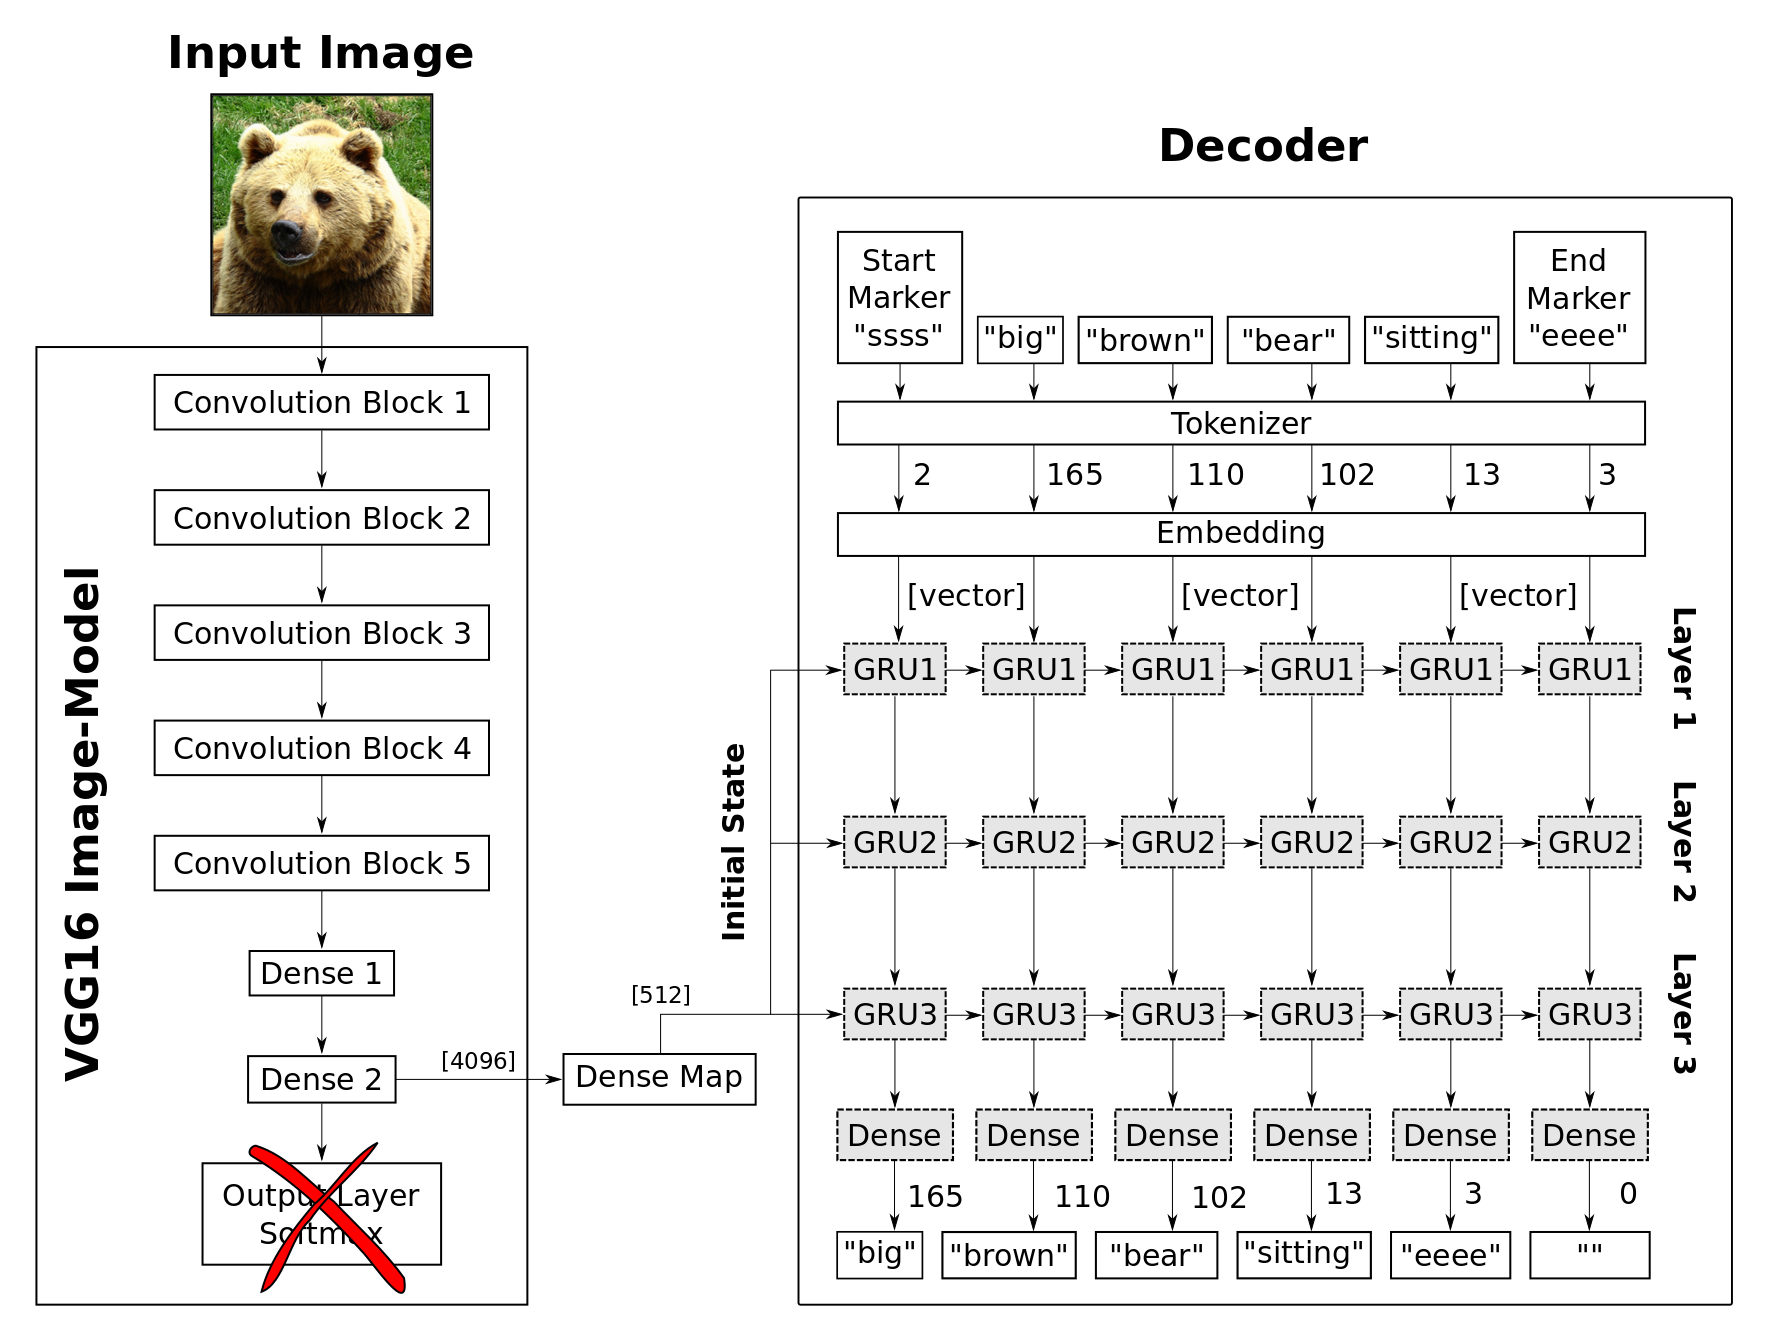

Dans cet exemple le captioning se fait de cette façon:
<ul>
    <li>L'image est passée à travers le CNN pour avoir une représentation compacte de celui-ci. Cette représentation est retournée par la couche `Dense 2` de taille 4096.</li>
    <li>Cette représentation est réduite en la passant à la couche dense `Dense Map` pour etre mise en entrée comme etat caché initial aux cellules du RNN.</li>
    <li>La partie RNN est composée de <a href="https://openclassrooms.com">GRU</a> (Gated Reccurent Unit). Cette partie est constituée de 3 couches. Une couche représentant de manière assez sommaire un niveau d'abstraction du langage. </li>
    <li>Le RNN a en entrée l'annotation ainsi que l'image en forme compacte, et retourne pour chaque colonne le mot suivant le mot en entrée au niveau de la colonne.</li>
    <li>Les annotations sont représentées en liste de mot. Cette liste est inexploitable par le RNN, elle est donc passée à un module qui remplace chaque mot par un entier (ou jeton entier), puis par un autre module qui projette chaque jeton en un vecteur dont les éléments sont entre -1 et 1.</li>
</ul>

Votre système d'annotation suivra de manière assez globale, le même principe que montrée dans l'image ci-dessous, néanmoins il contiendra des différences essentielles le distinguant de cet exemple. La système contiendra, notamment, un mécanisme d'attention (expliqué dans [article](https://arxiv.org/pdf/1502.03044.pdf) et dans [la video](https://www.youtube.com/watch?v=uCSTpOLMC48&list=WL&index=257)) dont la fonction est d'amener le réseau de neurones à donner une plus grande importance dans ses prédictions de l'annotation aux parties de l'images les plus parlantes et les plus pertinentes.

**L'encodeur CNN :**

L'encodeur CNN produit une représentation adéquate de l'image qu'il transmet au décodeur RNN pour la légender. Le CNN a en entrée les caractéristiques des images déjà prétraitées par InceptionV3 et stockées sur disque. 

Petite remarque, dans la partie CNN de ce réseau de neurones, la dernière couche convolutive n’est pas aplatie comme dans le cas du précédent workshop sur les CNNs. Rappelez-vous que les images issues du prétraitement par InceptionV3 étaient de la forme 8x8x2048. Ces images ont été remodelées pour avoir la taille 64x2048. Cela signifie que cette représentation contient pour chacune des 64 positions de l’image prétraitée les 2048 caractéristiques extraites par InveptoinV3. Et donc, l’entrée du décodeur CNN est un batch ou chaque élément est constitué des 2048 caractéristiques des 64 positions de l’image prétraitée (qui était à l’origine 8x8). La couche dense qui suit calcule une nouvelle représentation de l’image de taille 64x256 ou chaque position de l’image a donc 256 caractéristiques. Les poids sont les mêmes pour les neurones de mêmes position qui se trouvent sur la même colonne dans l’image prétraitée (qui sont associées à la même caractéristique de l’image). Ceci provient de la manière qu’a la [couche dense]( https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) de gérer les opérations matricielles dans tensorflow.

L’avantage de cette représentation par rapport à la représentation aplatie est de préserver de l’information spatiale au niveau des couches du réseau de neurones. Ceci permettra au mécanisme d’attention de la partie RNN de détecter les positions intéressantes au niveau de l’image et de renseigner l’algorithme sur quelle zone il devra porter le plus d’importance pour légender l’image.

In [10]:
class CNN_Encoder(tf.keras.Model):
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

**Le mécanisme d'attention :**

Le mécanisme d’attention ressemble beaucoup à une cellule [RNN classique]( https://fr.wikipedia.org/wiki/R%C3%A9seau_de_neurones_r%C3%A9currents), mais avec quelques différences. La partie de l’attention a en entrée la représentation de l’image prétraitée retournée par le CNN ainsi que la valeur courante de l’état cachée du GRU, et en sortie le **vecteur du contexte** qui reflète les caractéristiques les plus importantes de l’image. Une étape intermédiaire pour calculer ce vecteur consiste à calculer les **poids d’attention** qui représentent l’importance de chaque position de l’image (il y en a 64) dans la prédiction de son annotation.

La représentation de l’image donnée en entrée est transformée au début de la même manière que pour le CNN en la passant à une couche dense de taille `units`. De même, l’état caché est aussi passé à une couche dense de taille `units`. La nouvelle représentation de l’image est ensuite additionnée à l’état caché puis passée à une fonction d’activation de type [`tanh`](https://fr.wikipedia.org/wiki/Tangente_hyperbolique) comme pour les cellules classiques de RNN. À ce niveau-là, on aura une représentation des données de taille `64xunits` contenant un mélange d’informations sur l’image et sur le texte de l’annotation. Un score est ensuite associé à chacune des positions en passant cette représentation à une couche dense. Ces scores sont normalisés avec une couche softmax pour produire le vecteur des **poids d’attention**. 

Finalement, chaque caractéristique de la représentation de l’image en entrée sera multipliée (pondérée) par le vecteur d’attention. Après quoi, on prend la somme de chaque caractéristique le long des positions (les lignes de la représentation) pour former le **vecteur du contexte**.

De façon globale, on peut dire que le vecteur d’attention dépend de scores qui sont appris à partir d’une représentation spatiale et textuelle de l’image. Ce vecteur d’attention renvoie la pertinence de chaque position et sert à calculer le vecteur du contexte qui nous donnera l’importance des caractéristiques de l’image.

In [11]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):

            # Force hidden à être batché
        if tf.rank(hidden) == 1:
            hidden = tf.expand_dims(hidden, 0)

        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        attention_hidden_layer = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        score = self.V(attention_hidden_layer)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

**Le décodeur RNN :**

Le rôle du décodeur RNN est d’utiliser la représentation prétraitée de l’image de prédire sa légende mot par mot. Ce RNN à une seule cellule de type [GRU]( https://en.wikipedia.org/wiki/Gated_recurrent_unit). Le GRU a un état caché qui représente la mémoire des derniers éléments vu par celui-ci. Le GRU met à jour son état avant de le retourner, pour cela il utilise certains mécanismes de mémorisation qui sont assez sophistiqués.

Le décodeur est structuré comme suit, à chaque appel du RNN, le mot courant ainsi que la représentation de l’image et l’état caché du GRU sont donnés en entrée du RNN. Comme les mots sont représentés par des entiers, on doit faire passer ceux-ci par une couche dite [embedding layer]( https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) qui se chargera de calculer une représentation vectorielle de taille `output_dim` partant du nombre représentant le mot. 

À côté de ça, le mécanisme d’attention fournit un vecteur représentant **le contexte** de l’image c-à-d un vecteur qui nous renseigne sur les caractéristiques dominantes de l’image. Ce vecteur est calculé par un appel du mécanisme d’attention en lui fournissant en entrée les caractéristiques de l’image encodées par le CNN ainsi que l’état caché du GRU qui résume l’historique des mots vues par le RNN jusqu’à présent. 

Ensuite, le mot courant et le contexte sont concaténée pour former le vecteur d’entrée du GRU qui à son tour calcule l’état à l’étape suivante. Cet état est passée par une couche dense de taille `units` puis la sortie de cette couche est passée à une autre couche dense de taille `vocab_size` qui retourne le score associé à chaque mot du vocabulaire afin de prédire le mot suivant.

In [ ]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        # VERSION CPU
        # self.gru_cell = tf.keras.layers.GRUCell(self.units)
        # self.gru = tf.keras.layers.RNN(self.gru_cell,
        #                                return_sequences=True,
        #                                return_state=True)
        
        #  VERSION GPU
        # self.gru = tf.keras.layers.GRU(self.units,
        #                         return_sequences=True,
        #                         return_state=True,
        #                         recurrent_initializer='glorot_uniform')
        
        # VERSION GPU NVIDIA
        
        self.gru = tf.keras.layers.GRU(
        self.units,
        return_sequences=True,
        return_state=True,
        recurrent_initializer='glorot_uniform',
        recurrent_activation='sigmoid',  # ← nécessaire pour non-CuDNN
        reset_after=False                 # ← idem
        )
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        x.set_shape([None, 1, self.units])  
        gru_outputs = self.gru(x, initial_state=[hidden])
        #  VERSION GPU
        # gru_outputs = self.gru(x, initial_state=hidden)
        output = gru_outputs[0]
        state = gru_outputs[1]
        y = self.fc1(output)
        y = tf.reshape(y, (tf.shape(y)[0], tf.shape(y)[2]))
        y = self.fc2(y)
        return y, state, attention_weights

    # def reset_state(self, batch_size):
    #     batch_size = tf.cast(batch_size, tf.int32)
    #     return tf.zeros([batch_size, self.units], dtype=tf.float32)

**Combiner la partie encodeur et décodeur :**

Vous devez compléter la partie du code pour la création de l'encodeur et du décodeur.

4843


In [ ]:
# Dimensions d'embedding et de l'état caché
embedding_dim = 256
units = 512

# Création de l'encodeur
encoder = CNN_Encoder(embedding_dim)

# Création du décodeur
decoder = RNN_Decoder(embedding_dim, units, vocab_size)


In [ ]:
# del decoder
# del encoder
# tf.keras.backend.clear_session()

In [17]:
# Optimiseur ADAM
optimizer = tf.keras.optimizers.Adam()

# La fonction de perte
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

Pour garder la trace de votre apprentissage et la sauvegarder, vous pouvez utiliser la classe [`tf.train.Checkpoint`](https://www.tensorflow.org/api_docs/python/tf/train/Checkpoint).

In [20]:
# Pour encoder
encoder.build(input_shape=(None, 64, 2048))  # Build le modèle sans appel

# Pour decoder
decoder.build(input_shape=[
    (None, 1),                  # x (token input)
    (None, 64, embedding_dim),  # features
    (None, units)               # hidden state
])

/home/fares/datascience/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'cnn__encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/fares/datascience/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'rnn__decoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [23]:
encoder.load_weights('./checkpoints/encoder.weights.h5')
decoder.load_weights('./checkpoints/decoder.weights.h5')
print("✅ Poids restaurés depuis les fichiers .h5")

✅ Poids restaurés depuis les fichiers .h5


In [19]:
checkpoint_path = "./../checkpoints/train"
ckpt = tf.train.Checkpoint(encoder=encoder,
                           decoder=decoder,
                           optimizer = optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

Restaurer le modèle

In [ ]:
#if ckpt_manager.latest_checkpoint:
#    ckpt.restore(ckpt_manager.latest_checkpoint)
#    print("✅ Checkpoint restauré depuis :", ckpt_manager.latest_checkpoint)
#else:
#    print("❌ Aucun checkpoint trouvé.")

✅ Checkpoint restauré depuis : ./checkpoints/train/ckpt-4


Initialisation de l'époque de début d’entrainement dans `start_epoch`. La classe `tf.train.Checkpoint` permet de poursuivre l’entrainement là ou vous l’avez laissé s’il avait été interrompu auparavant.

In [20]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    # Restaurer le dernier checkpoint dans checkpoint_path
    ckpt.restore(tf.train.latest_checkpoint(checkpoint_path)).expect_partial()
    print("couscous")

# 3 Entrainement et test :
Vous implémenterez ensuite les fonctions `train_step` et `evaluate` :

- La fonction `train_step` représente une étape de l'entrainement du réseau. Elle est composée de l'évaluation par l'encodeur du vecteur pré-calculé par InceptionV3. La sortie de cette étape sera transmise au décodeur qui se charge de prédire l'annotation mot par mot. La boucle pour prédire chaque mot et calculer la perte associée devra être implémenté dans cette fonction.
- La fonction `evaluate` servira à évaluer les performances du réseau sur le jeu de test. Elle est donc similaire à la fonction `train_step` sauf que la partie calcul de la fonction de perte est absente car il n'agit pas d'entrainer le réseau.</li>

Enfin, vous devez implémenter la partie du code qui fait l'entrainement et le test. Précisons que l'entrainement se fait ici par batch d'images.

# 3.1 Entrainement
La fonction qui permet d'achever une étape d'entrainement sur un batch d'images est `train_step`. La fonction a en entrée un batch d'images prétraitées ainsi que leurs annotations et retourne la perte associée à ce batch. 

L'état caché de la partie RNN est initialisé ainsi que le mot de départ avec le token de début. Les caractéristiques de l'image sont ensuite extraites par l’encodeur. Après cela, on parcourt le batch mot par mot pour prédire le mot suivant à l'aide du décodeur. Le décodeur utilise l'état caché, les caractéristiques de l'image ainsi que le mot précédent pour prédire le mot courant. Le décodeur met à jour l'état caché et le retourne ainsi que les prédictions du batch. La perte est calculée à partir des prédictions retournées par le décodeur et les annotations associées au batch.

Finalement, la perte globale ainsi que le gradient sont calculés et le réseau est mis à jour.

In [21]:
loss_plot = []
# @tf.function
def train_step(img_tensor, target):
    loss = 0.0
    seq_len = tf.shape(target)[1]
    batch_size = tf.shape(target)[0]
    hidden = tf.zeros((batch_size, decoder.units), dtype=tf.float32)
    start_token = tf.constant(tokenizer.word_index['<start>'], dtype=tf.int32)
    dec_input = tf.expand_dims(tf.repeat(start_token, batch_size), 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)
        for i in tf.range(1, seq_len):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
               # Forcer hidden à garder la forme 2D
            if tf.rank(hidden) == 1:
                hidden = tf.expand_dims(hidden, 0)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = loss / tf.cast(seq_len, tf.float32)
    trainable_variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss


Le code global contenant la boucle d'entrainement est présenté ci-dessous. Cette boucle parcours le jeu de données d'entrainement batch par batch et entraine le réseaux avec ceux-ci.

In [22]:
EPOCHS = 20

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0
    
    for (batch, (img_tensor, target)) in enumerate(dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 100 == 0:
            print ('Epoch {} Batch {} Loss {:.4f}'.format(
              epoch + 1, batch, batch_loss.numpy() / int(target.shape[1])))
    # sauvegarde de la perte
    loss_plot.append(total_loss / num_steps)

    if epoch % 5 == 0:
        ckpt_manager.save()

    print ('Epoch {} Loss {:.6f}'.format(epoch + 1,
                                         total_loss/num_steps))
    print ('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

# Affichage de la courbe d'entrainement
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

Epoch 1 Batch 0 Loss 2.0569
Epoch 1 Batch 100 Loss 1.1218
Epoch 1 Batch 200 Loss 0.9560
Epoch 1 Batch 300 Loss 0.8895
Epoch 1 Batch 400 Loss 0.8475
Epoch 1 Batch 500 Loss 0.7620
Epoch 1 Batch 600 Loss 0.6901


2025-04-22 15:13:52.831129: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1 Loss 0.920913
Time taken for 1 epoch 1653.2984700202942 sec

Epoch 2 Batch 0 Loss 0.7533
Epoch 2 Batch 100 Loss 0.6658
Epoch 2 Batch 200 Loss 0.5946


KeyboardInterrupt: 

In [ ]:
encoder.save_weights('./../models/encoder_captioning_excellent.weights.h5')

In [ ]:
decoder.save_weights('./../models/decoder_captioning_excellent.weights.h5')

# 3.2 Test
La fonction qui permet d'achever une étape d'evaluation pour le test est dans la cellule suivante. 

In [23]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = tf.zeros((1, decoder.units))

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()

        # predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()  
        predicted_id = tf.argmax(predictions[0]).numpy()
        result.append(tokenizer.index_word[predicted_id])

        if tokenizer.index_word[predicted_id] == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

# Fonction permettant la représentation de l'attention au niveau de l'image
def plot_attention(image, result, attention_plot):
    import matplotlib.pyplot as plt
    import numpy as np
    from PIL import Image

    temp_image = np.array(Image.open(image))

    len_result = len(result)
    fig = plt.figure(figsize=(12, 12))

    # Affiche l'image de base en haut
    ax = fig.add_subplot((len_result + 1) // 2 + 1, 2, 1)
    ax.set_title("Original Image")
    ax.imshow(temp_image)
    ax.axis("off")

    # Affiche les attentions
    for l in range(len_result):
        temp_att = np.resize(attention_plot[l], (8, 8))
        ax = fig.add_subplot((len_result + 1) // 2 + 1, 2, l + 2)
        ax.set_title(result[l])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
        ax.axis("off")

    plt.tight_layout()
    plt.show()


L'affichage de quelques exemples sur le résultat retourné par l'évaluation. 

Caption token ids: <start> A stove top in a storage type of room with several spices on the stove. <end>
Index word sample: [(1, '<unk>'), (2, 'a'), (3, '<start>'), (4, '<end>'), (5, 'on'), (6, 'of'), (7, 'the'), (8, 'in'), (9, 'with'), (10, 'and')]
Real Caption: <start> a stove top in a storage type of room with several spices on the stove <end>
Prediction Caption: a desk with a television and a fireplace and a fireplace <end>


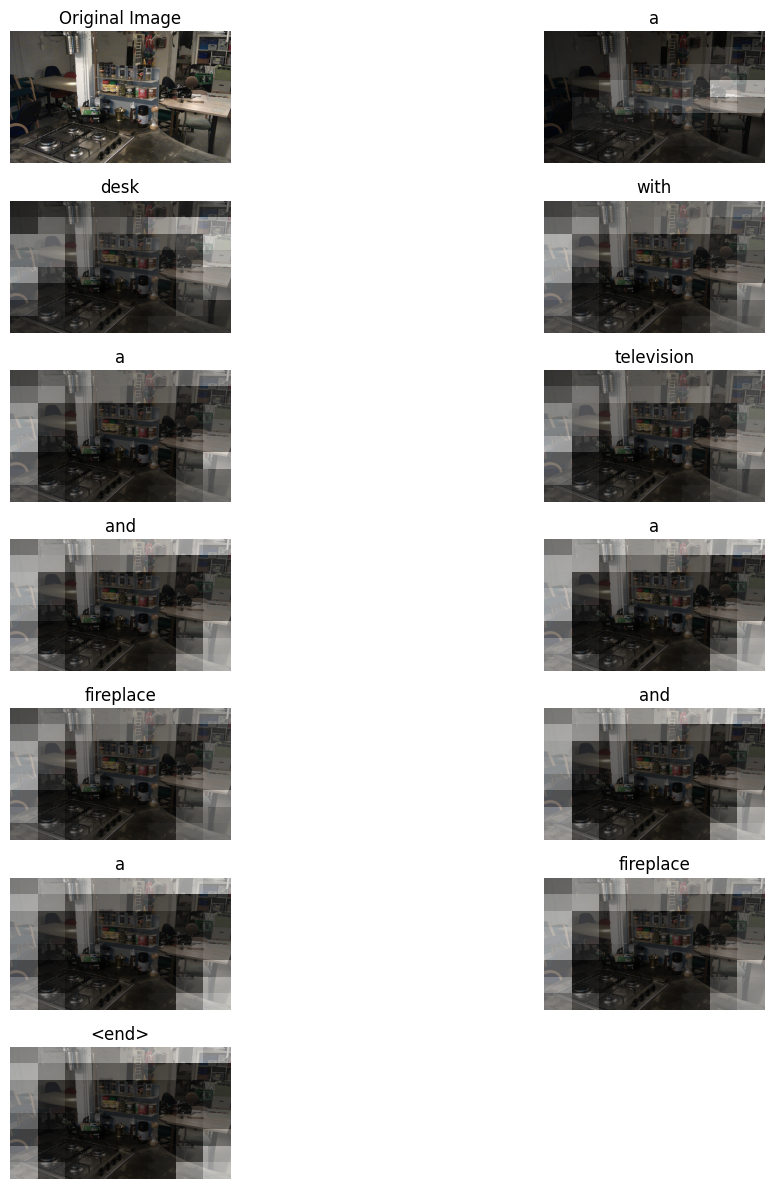

In [30]:
# Affichage de quelques annotations dans le jeu de test
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
print("Caption token ids:", cap_val[rid])
print("Index word sample:", list(tokenizer.index_word.items())[:10])
real_caption = ' '.join([
    tokenizer.index_word[i] for i in cap_val_vector[rid]
    if i not in [0] and i in tokenizer.index_word
])
result, attention_plot = evaluate(image)

print ('Real Caption:', real_caption)
print ('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)

In [ ]:
with open('./tokenizer/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Sauvegarde du tokenizer

In [ ]:
from src.utils import save_tokenizer

save_tokenizer(tokenizer)

# Chargement captioning (token et poids)
## Chargement du token de captioning à partir du JSON

In [ ]:
from src.utils import load_tokenizer
tokenizer_load = load_tokenizer()

## Chargement du modèle


In [ ]:
encoder_load = CNN_Encoder(embedding_dim)

decoder_load = RNN_Decoder(embedding_dim, units, vocab_size)

In [ ]:
vocab_size = len(tokenizer_load.word_index) + 1

def calc_max_length(tensor):
    return max(len(t) for t in tensor)

# Si tu as encore tes captions d'entraînement :
train_seqs = tokenizer_load.texts_to_sequences(train_captions)
max_length = calc_max_length(train_seqs) 

In [ ]:
encoder_load.build(input_shape=(None, 64, 2048))  # Build le modèle sans appel

# Pour decoder
decoder_load.build(input_shape=[
    (None, 1),                  # x (token input)
    (None, 64, embedding_dim),  # features
    (None, units)               # hidden state
])

encoder_load.load_weights('./../models/encoder_captioning_excellent.weights.h5', skip_mismatch=True)
decoder_load.load_weights('./../models/decoder_captioning_excellent.weights.h5', skip_mismatch=True)
print(":white_check_mark: Poids restaurés depuis les fichiers .h5")

In [ ]:
# Affichage de quelques annotations dans le jeu de test
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
print("Caption token ids:", cap_val[rid])
print("Index word sample:", list(tokenizer_load.index_word.items())[:10])
real_caption = ' '.join([
    tokenizer_load.index_word[i] for i in cap_val_vector[rid]
    if i not in [0] and i in tokenizer_load.index_word
])
result, attention_plot = evaluate(image, encoder_load, decoder_load, tokenizer_load)

print ('Real Caption:', real_caption)
print ('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)